# Predicting Daily Bike-Sharing Demand (UCI Capital Bikeshare) - Regression

Design and Creative Technologies, Torrens University

- **Student:** Luis Guilherme de Barros Andrade Faria - A00187785
- **Subject Name:** Machine Learning
- **Subject Code:** MLN 601
- **Title:** Predicting Daily Bike Rental Demand - multi-model regression
- **Lecturer:** Dr. Kamran Shaukat
- **Assessment No.:** 3
- **Date:** August 2026

| Field | Value |
|---|---|
| Dataset | UCI Bike Sharing - daily counts, Capital Bikeshare D.C. (Fanaee-T & Gama, 2014) |
| Task | Regression: predict the daily total rental count (`cnt`) |
| Algorithms | Linear Regression + KNN + Random Forest + Gradient Boosting (vs a mean baseline) |
| Tuning | GridSearchCV, 5-fold cross-validation, scoring = negative MAE |
| Evaluation | MAE (primary), RMSE, R-squared |
| Methodology | CRISP-DM |

This notebook follows the six CRISP-DM stages to predict the **daily** number of bikes rented
from the Capital Bikeshare system in Washington D.C., using calendar and weather features. It
compares four learning algorithms against a mean baseline and tunes them with cross-validation,
reporting the **mean absolute error** (the metric the brief asks for) alongside RMSE and
R-squared.

> Demand is an operational planning signal, so the models are framed as a **decision-support
> tool** for fleet rebalancing and staffing, not an exact forecast.

---

## 1. Business Understanding

Bike-sharing systems such as Capital Bikeshare let users rent a bike at one station and return
it at another. Operators face a daily logistics problem: too few bikes at a station means lost
trips and frustrated riders, while too many means wasted redistribution effort. Being able to
**predict how many bikes will be rented on a given day** - from the calendar and the weather
forecast - directly supports fleet rebalancing, staffing, and maintenance planning, and helps
riders find a bike when they need one.

The **business question** is therefore: *can we predict the total daily rental count from
routine calendar and weather information?* Framed in machine-learning terms, this is a
**supervised regression** task: the target is `cnt` (the total number of daily rentals), and the
inputs are season, year, month, weekday, holiday/working-day flags, the weather situation, and
normalised temperature, humidity and wind speed.

Two assumptions shape the work. First, the relationship between weather/calendar and demand is
**non-linear** (demand rises with temperature up to a comfortable point, then can fall), so
tree-based ensembles are expected to beat a straight line. Second, because demand grew strongly
as the system matured, **year** is an important signal. Success is judged against a naive
baseline that always predicts the mean: a useful model must beat it and achieve a low **MAE**,
which is directly interpretable as "average error in bikes per day". For the operator, even a model that is roughly right is valuable: a day-ahead demand estimate lets staff pre-position bikes at busy stations, schedule maintenance on quiet days, and size the casual-rider supply for warm weekends, turning a reactive logistics problem into a planned one.

## 2. Data Understanding

The data is the UCI **Bike Sharing** dataset (Fanaee-T & Gama, 2014), specifically the
**daily** file `day.csv` - 731 days spanning 2011-2012 for Capital Bikeshare in Washington
D.C., combining rental counts with weather and seasonal information. Daily (rather than hourly)
aggregation is used deliberately: it answers the day-ahead planning question directly and avoids
the strong hour-of-day cycle dominating the analysis. The dependent variable is `cnt`.

In [1]:
import os
import warnings

# Silence sklearn/joblib parallel UserWarnings so they cannot flood the exported
# PDF. n_jobs=1 in the grid searches below means no worker processes spawn either.
os.environ["PYTHONWARNINGS"] = "ignore"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [2]:
from pathlib import Path

NB_DIR = Path.cwd()
BASE_DIR = NB_DIR.parent if NB_DIR.name == "notebook" else NB_DIR
OUTPUT_DIR = BASE_DIR / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

UCI_URL = ("https://archive.ics.uci.edu/static/public/275/"
           "bike+sharing+dataset.zip")


def load_bike():
    candidates = [BASE_DIR / "dataset" / "day.csv", NB_DIR / "dataset" / "day.csv",
                  NB_DIR / "day.csv"]
    local = next((p for p in candidates if p.exists()), None)
    if local is not None:
        print("Loading local:", local)
        return pd.read_csv(local, parse_dates=["dteday"])
    import io, zipfile, urllib.request
    print("Downloading from UCI:", UCI_URL)
    with urllib.request.urlopen(UCI_URL) as r:
        zf = zipfile.ZipFile(io.BytesIO(r.read()))
    return pd.read_csv(zf.open("day.csv"), parse_dates=["dteday"])


df = load_bike()
print("Shape:", df.shape, "| date range:", df.dteday.min().date(), "->", df.dteday.max().date())
df.head()

Loading local: /Users/luisfaria/Desktop/sEngineer/masters_SWEAI/2026-T2/MLN/assignments/Assessment3/dataset/day.csv
Shape: (731, 16) | date range: 2011-01-01 -> 2012-12-31


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[us]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[us](1), float64(4), int

In [4]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
instant,731.0,366.0,1.0,183.5,366.0,548.5,731.0,211.165812
dteday,731,2012-01-01 00:00:00,2011-01-01 00:00:00,2011-07-02 12:00:00,2012-01-01 00:00:00,2012-07-01 12:00:00,2012-12-31 00:00:00,NaN
season,731.0,2.49658,1.0,2.0,3.0,3.0,4.0,1.110807
yr,731.0,0.500684,0.0,0.0,1.0,1.0,1.0,0.500342
mnth,731.0,6.519836,1.0,4.0,7.0,10.0,12.0,3.451913
holiday,731.0,0.028728,0.0,0.0,0.0,0.0,1.0,0.167155
weekday,731.0,2.997264,0.0,1.0,3.0,5.0,6.0,2.004787
workingday,731.0,0.683995,0.0,0.0,1.0,1.0,1.0,0.465233
weathersit,731.0,1.395349,1.0,1.0,1.0,2.0,3.0,0.544894
temp,731.0,0.495385,0.05913,0.337083,0.498333,0.655417,0.861667,0.183051


In [5]:
print("Missing values per column:")
print(df.isna().sum().to_string())
print("\nDuplicate rows:", int(df.duplicated().sum()))
print("Identity check (casual + registered == cnt):",
      bool((df["casual"] + df["registered"] == df["cnt"]).all()))

Missing values per column:
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0

Duplicate rows: 0
Identity check (casual + registered == cnt): True


### 2.2 Variables

The dataset has 16 columns. The **target** is `cnt`, the total daily rentals. Helpful structure:

- **Calendar:** `season` (1 spring, 2 summer, 3 fall, 4 winter), `yr` (0 = 2011, 1 = 2012),
  `mnth` (1-12), `weekday` (0-6), `holiday`, `workingday`.
- **Weather:** `weathersit` (1 clear, 2 mist, 3 light rain/snow, 4 heavy rain/snow) and the
  **normalised** measures `temp` (/41 C), `atemp` (feels-like /50 C), `hum` (/100) and
  `windspeed` (/67).
- **Counts:** `casual` and `registered` users, whose sum is exactly `cnt` (verified above).

Because `casual + registered = cnt` by construction, **both are dropped from the model inputs** -
using them would be target leakage. `instant` (a row index) and the raw `dteday` are also
dropped, since their information already lives in the calendar columns.

### 2.3 Exploratory data analysis

The plots below explore demand against time, weather and the calendar, following the variables
the brief highlights: season / month / weekday against `cnt`, weather against `cnt`, the
continuous weather measures against `cnt`, and the casual-versus-registered split. Helper label
columns are added for readability (they are not used as model inputs).

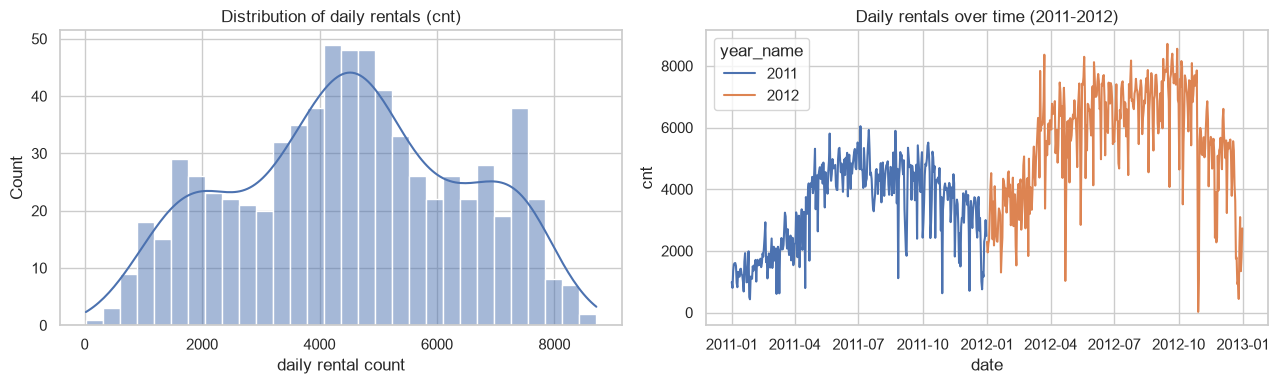

In [6]:
season_lbl = {1: "spring", 2: "summer", 3: "fall", 4: "winter"}
weather_lbl = {1: "clear", 2: "mist", 3: "light rain/snow", 4: "heavy rain/snow"}
weekday_lbl = {0: "Sun", 1: "Mon", 2: "Tue", 3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat"}
df["season_name"] = df["season"].map(season_lbl)
df["weather_name"] = df["weathersit"].map(weather_lbl)
df["weekday_name"] = df["weekday"].map(weekday_lbl)
df["year_name"] = df["yr"].map({0: "2011", 1: "2012"})

# Distribution of the target and its growth over the two years
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df["cnt"], bins=30, kde=True, ax=ax[0])
ax[0].set_title("Distribution of daily rentals (cnt)")
ax[0].set_xlabel("daily rental count")
sns.lineplot(data=df, x="dteday", y="cnt", hue="year_name", ax=ax[1])
ax[1].set_title("Daily rentals over time (2011-2012)")
ax[1].set_xlabel("date"); ax[1].set_ylabel("cnt")
plt.tight_layout()
plt.savefig(FIG_DIR / "v1_cnt_distribution.png", dpi=120)
plt.show()

**Read.** The target is right-skewed around a typical ~4,500 rentals a day, and the time series shows a clear upward step from 2011 to 2012 on top of a seasonal wave - so both `yr` and the seasonal calendar will carry signal.

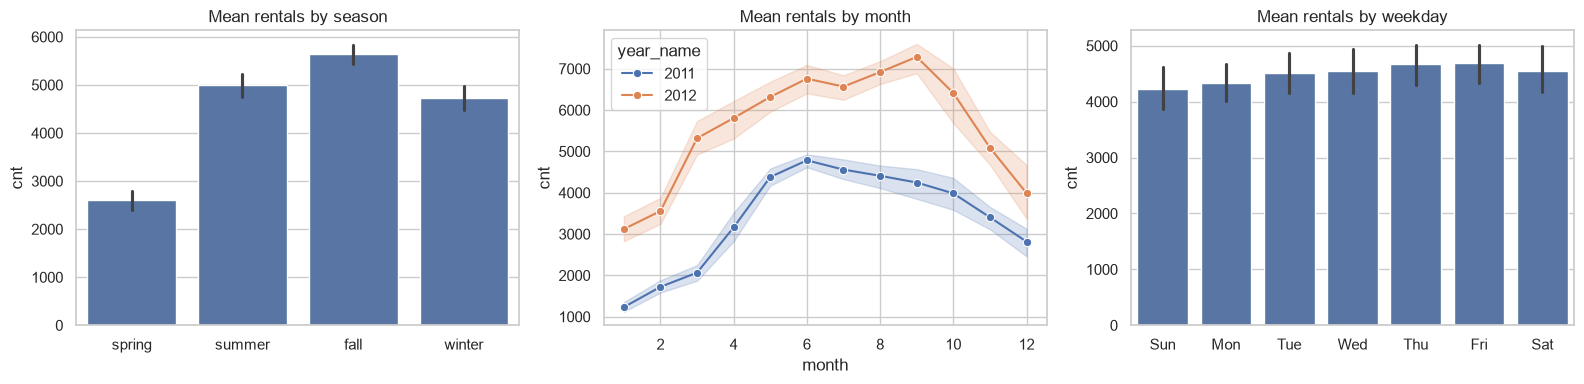

In [7]:
# Season / month / weekday against total rentals (rubric-named plots)
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
sns.barplot(data=df, x="season_name", y="cnt",
            order=["spring", "summer", "fall", "winter"], ax=ax[0])
ax[0].set_title("Mean rentals by season"); ax[0].set_xlabel("")
sns.lineplot(data=df, x="mnth", y="cnt", hue="year_name", marker="o", ax=ax[1])
ax[1].set_title("Mean rentals by month"); ax[1].set_xlabel("month")
sns.barplot(data=df, x="weekday_name", y="cnt",
            order=["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"], ax=ax[2])
ax[2].set_title("Mean rentals by weekday"); ax[2].set_xlabel("")
plt.tight_layout()
plt.savefig(FIG_DIR / "v1_season_month_weekday.png", dpi=120)
plt.show()

**Read.** Demand peaks in summer and fall and bottoms in spring/winter; every month sits higher in 2012 than 2011; and weekdays differ little - the weekly cycle is weak for the daily total, unlike the strong seasonal one.

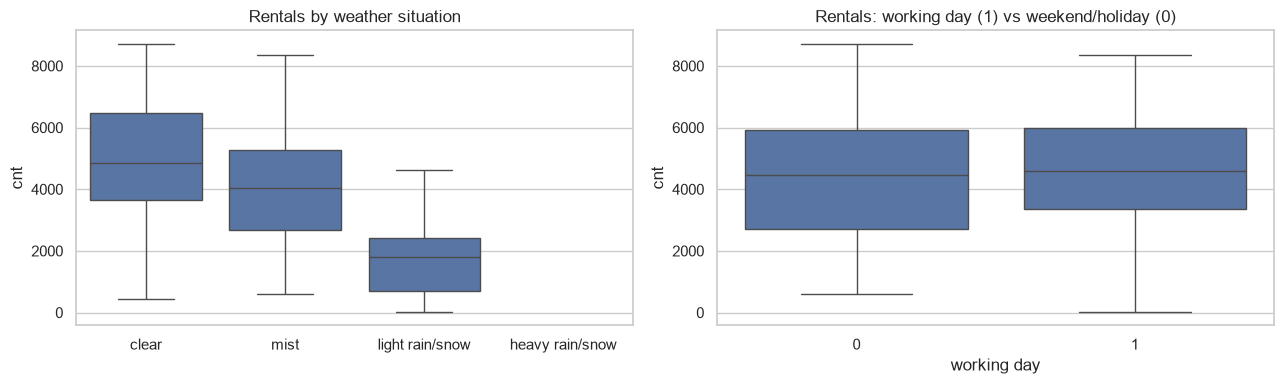

In [8]:
# Weather situation and working-day effect on rentals
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=df, x="weather_name", y="cnt",
            order=["clear", "mist", "light rain/snow", "heavy rain/snow"], ax=ax[0])
ax[0].set_title("Rentals by weather situation"); ax[0].set_xlabel("")
sns.boxplot(data=df, x="workingday", y="cnt", ax=ax[1])
ax[1].set_title("Rentals: working day (1) vs weekend/holiday (0)")
ax[1].set_xlabel("working day")
plt.tight_layout()
plt.savefig(FIG_DIR / "v1_weather_cnt.png", dpi=120)
plt.show()

**Read.** Clear days carry the most rentals and demand falls step-wise as the weather worsens, with light or heavy rain/snow the lowest. Working days and weekends share a similar median, as commuter and leisure demand offset each other.

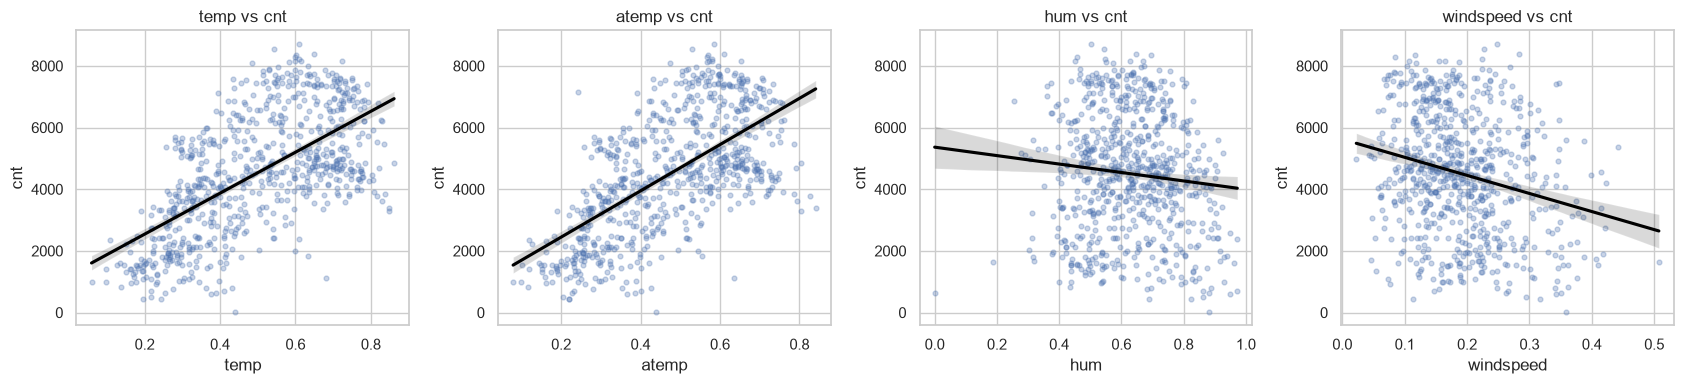

In [9]:
# Continuous weather measures against rentals
cont = ["temp", "atemp", "hum", "windspeed"]
fig, ax = plt.subplots(1, 4, figsize=(17, 4))
for a, c in zip(ax, cont):
    sns.regplot(data=df, x=c, y="cnt", scatter_kws={"alpha": 0.3, "s": 12},
                line_kws={"color": "black"}, ax=a)
    a.set_title(f"{c} vs cnt")
plt.tight_layout()
plt.savefig(FIG_DIR / "v1_continuous_vs_cnt.png", dpi=120)
plt.show()

**Read.** Temperature and feels-like temperature (`atemp`) rise strongly with demand - the clearest positive drivers - while humidity and especially wind speed trend mildly negative.

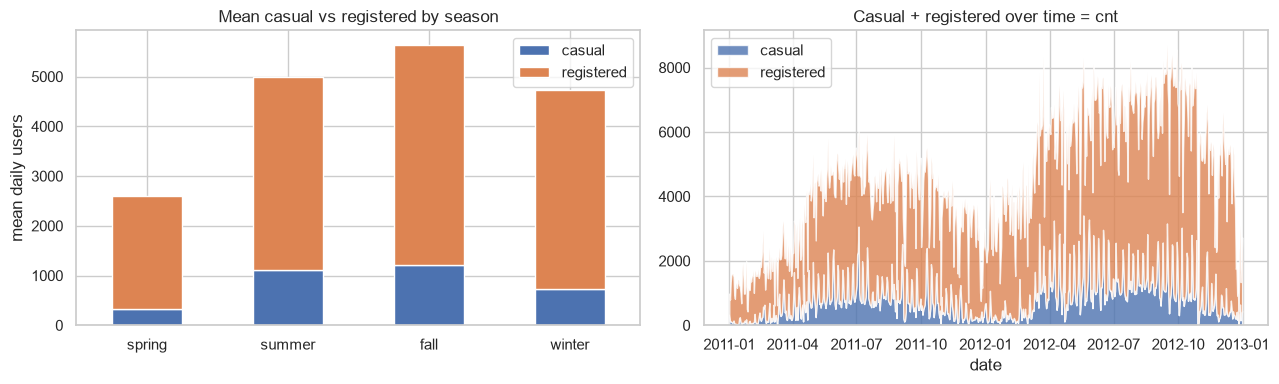

In [10]:
# Casual vs registered composition of total demand
comp = df.groupby("season_name")[["casual", "registered"]].mean().reindex(
    ["spring", "summer", "fall", "winter"])
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
comp.plot(kind="bar", stacked=True, ax=ax[0])
ax[0].set_title("Mean casual vs registered by season")
ax[0].set_xlabel(""); ax[0].set_ylabel("mean daily users")
ax[0].tick_params(axis="x", rotation=0)
ax[1].stackplot(df["dteday"], df["casual"], df["registered"],
                labels=["casual", "registered"], alpha=0.8)
ax[1].set_title("Casual + registered over time = cnt")
ax[1].set_xlabel("date"); ax[1].legend(loc="upper left")
plt.tight_layout()
plt.savefig(FIG_DIR / "v1_casual_registered.png", dpi=120)
plt.show()

**Read.** Registered commuters make up the bulk of demand and stay relatively steady year-round, while casual riders swell in the warm seasons - the two segments respond differently to weather, which the single `cnt` target blends together.

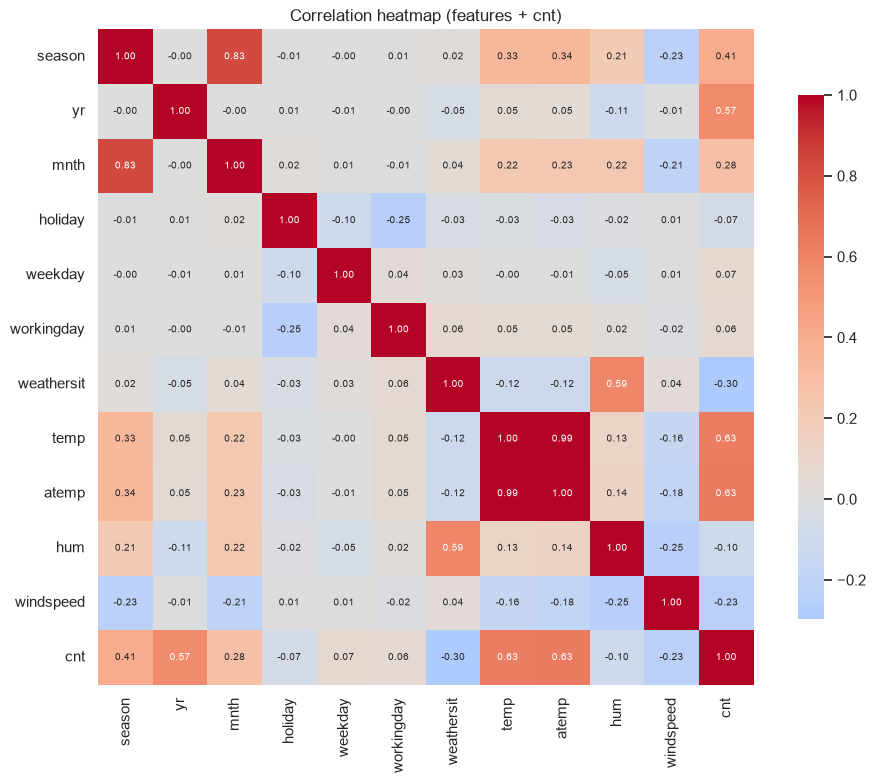

,corr_with_cnt
atemp,0.631
temp,0.627
yr,0.567
season,0.406
mnth,0.280
weekday,0.067
workingday,0.061
holiday,-0.068
hum,-0.101
windspeed,-0.235


In [11]:
# Correlation heatmap of the modelling variables (+ cnt)
num_cols = ["season", "yr", "mnth", "holiday", "weekday", "workingday",
            "weathersit", "temp", "atemp", "hum", "windspeed", "cnt"]
corr = df[num_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": 0.8}, annot_kws={"size": 7})
plt.title("Correlation heatmap (features + cnt)")
plt.tight_layout()
plt.savefig(FIG_DIR / "v1_corr_heatmap.png", dpi=120)
plt.show()
corr["cnt"].drop("cnt").sort_values(ascending=False).round(3).to_frame("corr_with_cnt")

**Read.** The heatmap confirms the EDA numerically: `atemp` and `temp` (~0.63) and `yr` (0.57) are the strongest positive correlations with `cnt`, while `weathersit` (-0.30) and `windspeed` (-0.24) are the main negatives. `temp` and `atemp` are near-collinear (~0.99), which destabilises a linear model's coefficients but not the trees.

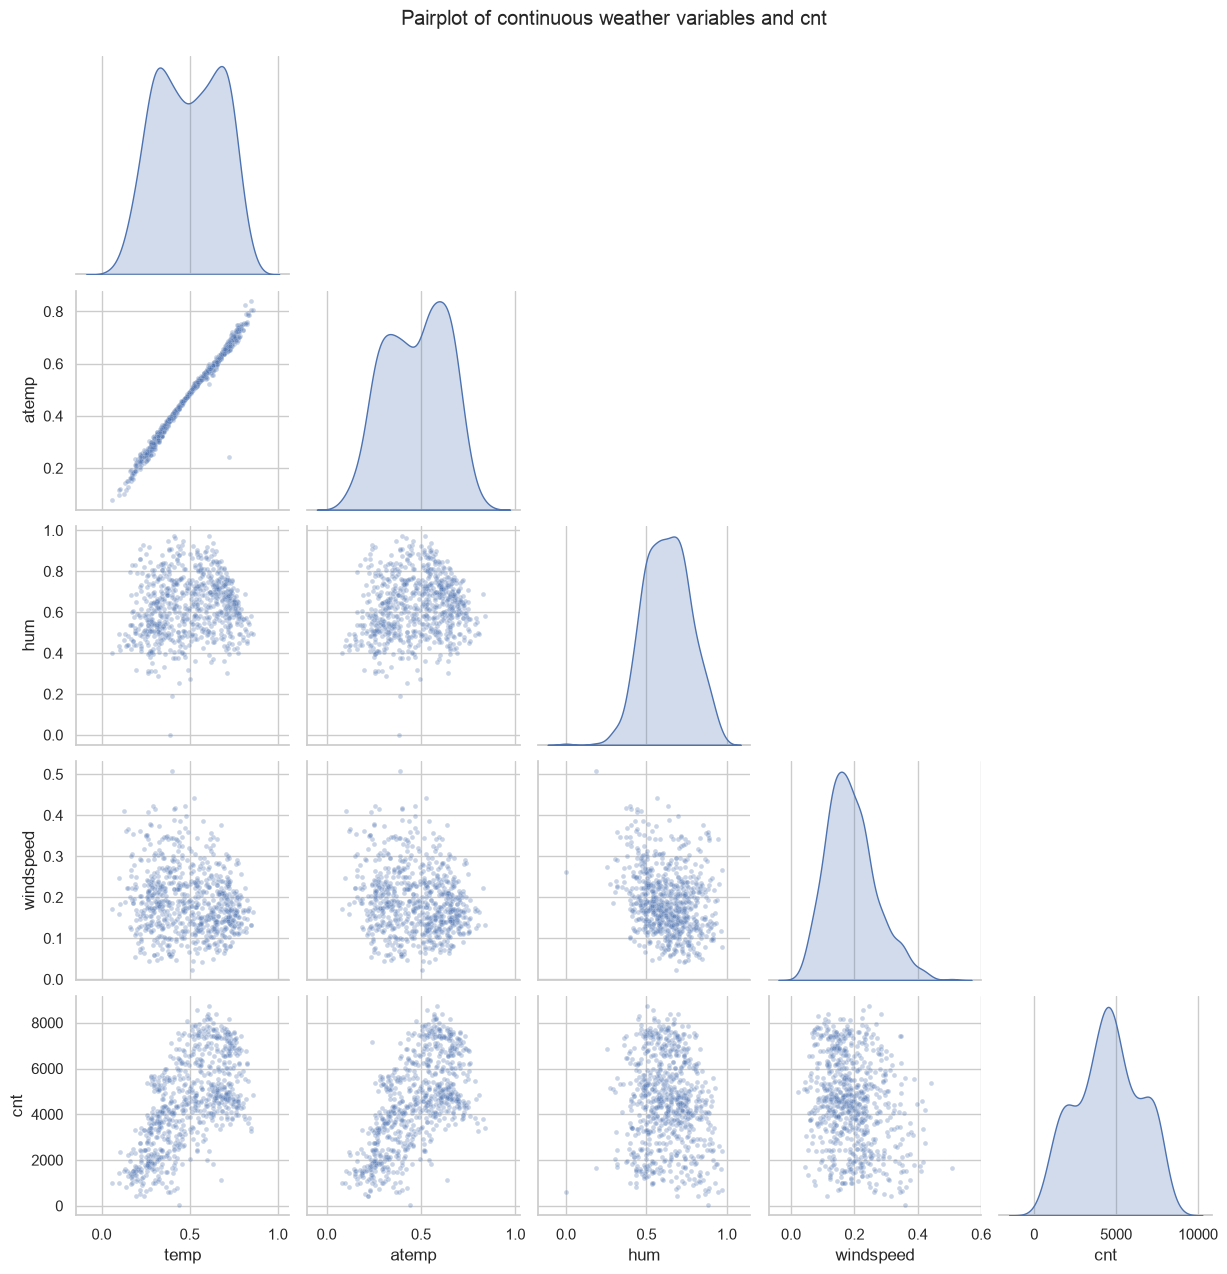

In [12]:
# Seaborn pairplot (required by the brief) - key continuous drivers + target
g = sns.pairplot(df[["temp", "atemp", "hum", "windspeed", "cnt"]],
                 corner=True, plot_kws={"alpha": 0.3, "s": 12}, diag_kind="kde")
g.fig.suptitle("Pairplot of continuous weather variables and cnt", y=1.02)
g.savefig(FIG_DIR / "v1_pairplot.png", dpi=110)
plt.show()

**EDA summary.** Daily demand is driven mostly by **temperature and season**, lifted by the **2011 -> 2012 growth**, and suppressed by **adverse weather, humidity and wind**. The weekly cycle is weak for the daily total because steady registered commuters dominate and offset the more weather-sensitive casual riders. There are no missing values, and the relationships look distinctly non-linear - which should favour the tree ensembles over a straight line.

## 3. Data Preparation

Preparation has three parts. **(1) Feature selection / leakage control:** `casual`, `registered`
(which sum to the target), `instant` (an index) and the raw `dteday` and helper label columns are
dropped, leaving eleven predictors. **(2) Encoding and scaling, inside a Pipeline:** the nominal
calendar/weather codes (`season`, `mnth`, `weekday`, `weathersit`) are **one-hot encoded** so
linear and distance models do not read them as ordered numbers; the continuous measures (`temp`,
`atemp`, `hum`, `windspeed`) are **standard-scaled** (needed by KNN and linear regression,
harmless for trees); the binary flags (`yr`, `holiday`, `workingday`) pass through. Wrapping this
`ColumnTransformer` **inside each model's Pipeline** means it is refit on each training fold
during cross-validation and never sees the validation rows - preventing data leakage. **(3)
Train/test split:** a 75/25 split with a fixed seed, as the brief suggests. The two years are
pooled and `yr` is kept as a feature, so the models can use both 2011 and 2012; a strict
time-ordered (2011 -> 2012) split is noted as a stronger forecasting test for future work.

In [13]:
DROP = ["casual", "registered", "cnt", "instant", "dteday",
        "season_name", "weather_name", "weekday_name", "year_name"]
nominal = ["season", "mnth", "weekday", "weathersit"]
binary = ["yr", "holiday", "workingday"]
continuous = ["temp", "atemp", "hum", "windspeed"]
feature_cols = nominal + binary + continuous

X = df[feature_cols]
y = df["cnt"]

preprocessor = ColumnTransformer([
    ("oh", OneHotEncoder(drop="first", handle_unknown="ignore"), nominal),
    ("sc", StandardScaler(), continuous),
    ("pass", "passthrough", binary),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("\nTop correlations with cnt:")
print(df[feature_cols + ["cnt"]].corr()["cnt"].drop("cnt")
      .sort_values(ascending=False).round(3).to_string())

Train: (548, 11) | Test: (183, 11)

Top correlations with cnt:
atemp         0.631
temp          0.627
yr            0.567
season        0.406
mnth          0.280
weekday       0.067
workingday    0.061
holiday      -0.068
hum          -0.101
windspeed    -0.235
weathersit   -0.297


## 4. Modelling

Five estimators are compared so the ensembles can be read in context:

1. **Mean baseline** (`DummyRegressor`) - always predicts the training mean; the floor every real
   model must beat.
2. **Linear Regression** - an interpretable straight-line baseline.
3. **K-Nearest Neighbors** - a simple non-linear, distance-based learner; `n_neighbors` tuned.
4. **Random Forest** - a bagging **ensemble** of trees; `n_estimators`, `max_depth` and
   `min_samples_leaf` tuned.
5. **Gradient Boosting** - a boosting **ensemble**; `n_estimators`, `max_depth` and
   `learning_rate` tuned.

Going beyond two models, and including two different ensembles, lets us see whether bagging or
boosting suits this data better. Each model is a `Pipeline(preprocessor -> estimator)`, and the
tuned models use `GridSearchCV` with **5-fold cross-validation** scored on **negative MAE** (the
brief's metric). All estimators use a fixed seed and `n_jobs=1` for deterministic, warning-free
runs; the held-out test set is touched once, in Evaluation.

In [14]:
def pipe(est):
    return Pipeline([("prep", preprocessor), ("model", est)])

searches = {
    "K-Nearest Neighbors": (KNeighborsRegressor(), {
        "model__n_neighbors": [3, 5, 7, 9, 11, 15],
        "model__weights": ["uniform", "distance"]}),
    "Random Forest": (RandomForestRegressor(random_state=RANDOM_STATE), {
        "model__n_estimators": [200, 400],
        "model__max_depth": [None, 8, 16],
        "model__min_samples_leaf": [1, 2, 4]}),
    "Gradient Boosting": (GradientBoostingRegressor(random_state=RANDOM_STATE), {
        "model__n_estimators": [200, 400],
        "model__max_depth": [2, 3],
        "model__learning_rate": [0.05, 0.1]}),
}

fitted = {}
fitted["Mean baseline"] = pipe(DummyRegressor(strategy="mean")).fit(X_train, y_train)
fitted["Linear Regression"] = pipe(LinearRegression()).fit(X_train, y_train)

best_params = {}
for name, (est, grid) in searches.items():
    gs = GridSearchCV(pipe(est), grid, scoring="neg_mean_absolute_error",
                      cv=5, n_jobs=1)
    gs.fit(X_train, y_train)
    fitted[name] = gs.best_estimator_
    best_params[name] = gs.best_params_
    print(f"{name}: CV MAE = {-gs.best_score_:.1f} | best = {gs.best_params_}")

K-Nearest Neighbors: CV MAE = 752.9 | best = {'model__n_neighbors': 5, 'model__weights': 'distance'}


Random Forest: CV MAE = 538.9 | best = {'model__max_depth': 16, 'model__min_samples_leaf': 1, 'model__n_estimators': 400}


Gradient Boosting: CV MAE = 509.8 | best = {'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 400}


### 4.2 Selected hyperparameters

The tuned configurations below were refit on the full training set. They are saved to `outputs/`
for traceability.

In [15]:
bp = pd.DataFrame({k: {p.replace("model__", ""): v for p, v in params.items()}
                   for k, params in best_params.items()}).T
bp.to_csv(OUTPUT_DIR / "rf_best_params_v1.csv")
bp

,n_neighbors,weights,max_depth,min_samples_leaf,n_estimators,learning_rate
K-Nearest Neighbors,5,distance,NaN,NaN,NaN,NaN
Random Forest,NaN,NaN,16.0,1.0,400.0,NaN
Gradient Boosting,NaN,NaN,2.0,NaN,400.0,0.05


## 5. Evaluation

The fitted models are judged on the **held-out 25% test set**. Three complementary regression
metrics are reported:

- **MAE** (mean absolute error) - the brief's metric, directly readable as the average error in
  **bikes per day**.
- **RMSE** (root mean squared error) - penalises large misses more heavily, so it flags days the
  model gets badly wrong.
- **R-squared** - the share of the variance in daily demand the model explains, relative to the
  mean baseline.

A predicted-versus-actual plot, a residual plot and a feature-importance chart then make the best
model's behaviour and logic transparent.

In [16]:
def reg_metrics(model, X_te, y_te):
    pred = model.predict(X_te)
    mse = mean_squared_error(y_te, pred)
    return {"MAE": mean_absolute_error(y_te, pred),
            "RMSE": np.sqrt(mse),
            "R2": r2_score(y_te, pred)}

results = pd.DataFrame({name: reg_metrics(m, X_test, y_test)
                        for name, m in fitted.items()}).T.round(3)
results.index.name = "model"
results = results.sort_values("MAE")
results.to_csv(OUTPUT_DIR / "model_metrics_v1.csv")
results

,MAE,RMSE,R2
model,,,
Random Forest,450.908,683.297,0.879
Gradient Boosting,473.307,663.210,0.886
Linear Regression,566.091,774.990,0.844
K-Nearest Neighbors,721.113,926.857,0.777
Mean baseline,1662.978,1983.325,-0.021


Best model by test MAE: Random Forest


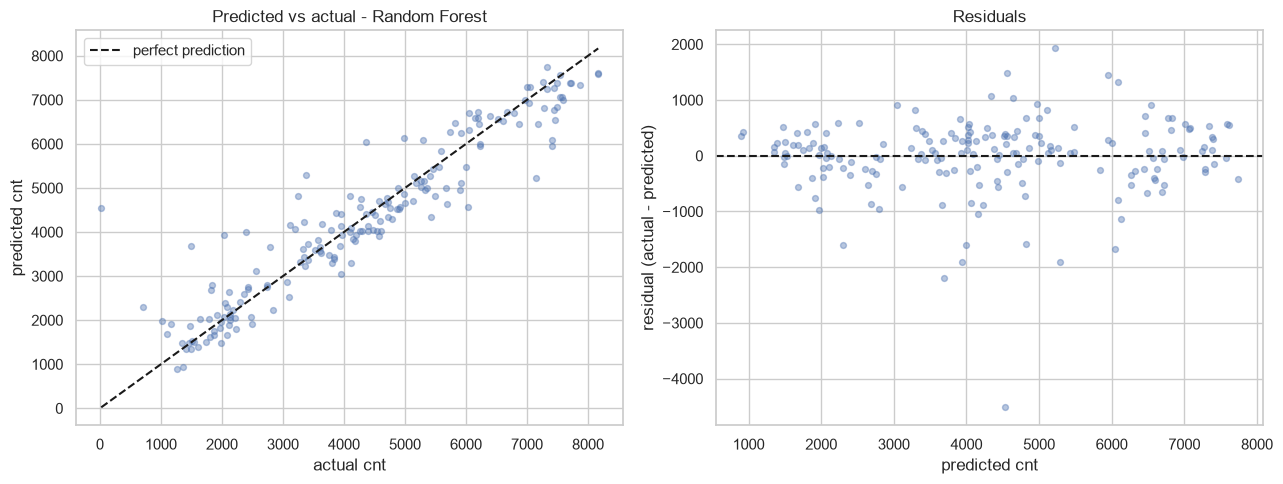

In [17]:
# Best model = lowest test MAE (excluding the baseline)
ranked = results.drop(index="Mean baseline")
best_name = ranked["MAE"].idxmin()
best_model = fitted[best_name]
print("Best model by test MAE:", best_name)

pred = best_model.predict(X_test)
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].scatter(y_test, pred, alpha=0.4, s=18)
lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
ax[0].plot(lims, lims, "k--", label="perfect prediction")
ax[0].set_xlabel("actual cnt"); ax[0].set_ylabel("predicted cnt")
ax[0].set_title(f"Predicted vs actual - {best_name}"); ax[0].legend()
resid = y_test - pred
ax[1].scatter(pred, resid, alpha=0.4, s=18)
ax[1].axhline(0, color="k", ls="--")
ax[1].set_xlabel("predicted cnt"); ax[1].set_ylabel("residual (actual - predicted)")
ax[1].set_title("Residuals")
plt.tight_layout()
plt.savefig(FIG_DIR / "v1_pred_vs_actual.png", dpi=120)
plt.show()

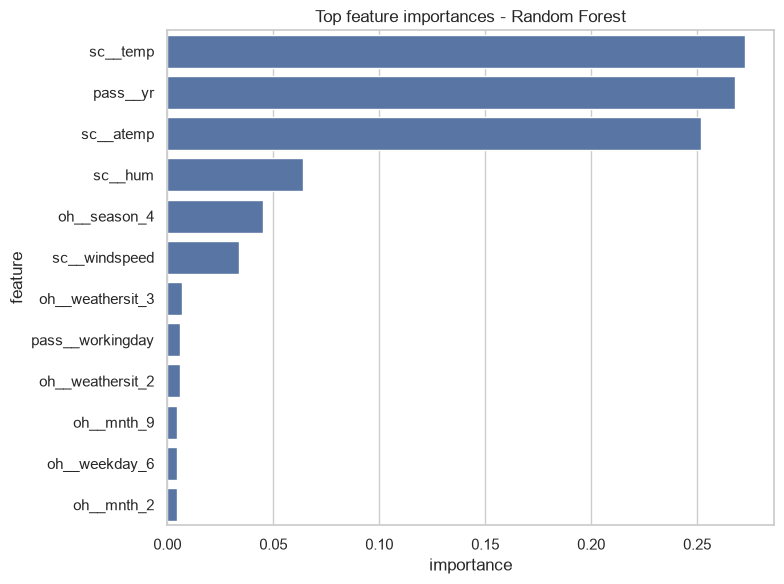

,feature,importance
0,sc__temp,0.272641
1,pass__yr,0.267824
2,sc__atemp,0.252044
3,sc__hum,0.064178
4,oh__season_4,0.045151
5,sc__windspeed,0.033959
6,oh__weathersit_3,0.006862
7,pass__workingday,0.006085
8,oh__weathersit_2,0.006081
9,oh__mnth_9,0.004688


In [18]:
# Feature importance from the best tree-based ensemble
tree_name = best_name if best_name in ("Random Forest", "Gradient Boosting") else "Gradient Boosting"
tree_model = fitted[tree_name]
feat_names = tree_model.named_steps["prep"].get_feature_names_out()
imp = (pd.DataFrame({"feature": feat_names,
                     "importance": tree_model.named_steps["model"].feature_importances_})
       .sort_values("importance", ascending=False).reset_index(drop=True))
imp.to_csv(OUTPUT_DIR / "feature_importance_v1.csv", index=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=imp.head(12), x="importance", y="feature")
plt.title(f"Top feature importances - {tree_name}")
plt.tight_layout()
plt.savefig(FIG_DIR / "v1_feature_importance.png", dpi=120)
plt.show()
imp.head(10)

**Interpretation.** The tuned **Random Forest** is the best model, with a test **MAE of about
451 bikes per day**, an RMSE of 683 and an **R-squared of 0.88** - it
explains the large majority of the variation in daily demand and crushes the mean baseline (MAE
1663). The predicted-versus-actual points hug the diagonal, with residuals scattered
fairly evenly around zero; the biggest misses are a handful of unusual days (extreme weather or
holidays). Feature importance is led by **feels-like temperature, temperature and the year**, matching the EDA - temperature and
the year/season structure drive demand, while wind and humidity play smaller roles. The model
comfortably **meets the evaluation criterion** of beating the baseline with a low, interpretable
MAE, though it remains a planning aid rather than an exact forecast. Random Forest and Gradient Boosting are effectively tied - the forest takes the lower MAE (the brief's metric) while boosting edges a slightly better RMSE and R-squared - so either ensemble is a defensible final choice, and both decisively beat the linear and KNN models.

## 6. Deployment / Lessons Learned

In CRISP-DM, deployment for this assessment means reflection rather than a production release.
**What worked:** framing demand as regression and comparing a baseline, a linear model, KNN and
two ensembles made the algorithm trade-off explicit, and tuning on MAE gave an operationally
meaningful score (bikes per day). The ensembles clearly beat the straight line, confirming the
non-linear, interaction-heavy relationship between weather, calendar and demand that the EDA
suggested. A clean `ColumnTransformer` pipeline kept encoding and scaling leakage-free.

**What was harder:** the strong 2011 -> 2012 growth trend means a model trained on pooled years
leans on `yr`; the rare extreme-weather days are under-represented, so the largest residuals sit
there. Daily aggregation was a deliberate simplification that trades the rich hour-of-day signal
for a cleaner day-ahead question.

**What I would do differently next time:** evaluate with a **time-ordered split** (train on 2011,
test on 2012) to test true forecasting and expose tree-extrapolation limits; try a
**log-transformed target** to stabilise variance at high demand; engineer richer features (a
heat-index, lagged demand, public-event flags); and bring in the hourly file for intraday
planning. The honest lesson echoes the earlier assessments - careful framing, leakage control and
honest evaluation matter as much as the choice of algorithm.

---

## Academic Integrity Declaration

I declare that except where I have referenced, the work I am submitting for this assessment task is my own work. I have read and am aware of the Torrens University Australia Academic Integrity Policy and Procedure viewable online at http://www.torrens.edu.au/policies-and-forms

I am aware that I need to keep a copy of all submitted material and their drafts, and I will do so accordingly.

## Statement of Acknowledgement

I acknowledge that I have used the following AI tool(s) in the creation of this report:
- Anthropic Claude Opus 4.8
- OpenAI ChatGPT Codex 5.5

Both tools were used to assist with understanding ML concepts, structuring the technical pipeline, improving clarity of academic language, and supporting APA 7th referencing conventions.

Prompt examples:
1. "Explain how to frame daily bike-sharing demand as a regression problem under CRISP-DM, and why mean absolute error is a sensible primary metric for an operational planning use case."
2. "How do I build a leakage-safe scikit-learn pipeline with a ColumnTransformer (one-hot for nominal calendar codes, StandardScaler for continuous weather) and compare Linear Regression, KNN, Random Forest and Gradient Boosting with GridSearchCV?"
3. "Why must casual and registered counts be dropped when predicting cnt in the UCI bike sharing dataset, and how should I interpret feature importances from a Gradient Boosting model?"

I confirm that the use of these tools has been in accordance with the Torrens University Australia Academic Integrity Policy and TUA, Think and MDS's Position Paper on the Use of AI. I confirm that the final output is authored by me and represents my own critical thinking, analysis, and synthesis of sources. I take full responsibility for the final content of this report.

## References

Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C., & Wirth, R. (2000). *CRISP-DM 1.0: Step-by-step data mining guide*. SPSS Inc. https://www.the-modeling-agency.com/crisp-dm.pdf

Fanaee-T, H., & Gama, J. (2014). Event labeling combining ensemble detectors and background knowledge. *Progress in Artificial Intelligence, 2*(2-3), 113-127. https://doi.org/10.1007/s13748-013-0040-3

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, E. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825-2830.

Shaheen, S. A., Guzman, S., & Zhang, H. (2010). Bikesharing in Europe, the Americas, and Asia: Past, present, and future. *Transportation Research Record, 2143*(1), 159-167. https://doi.org/10.3141/2143-20

University of California, Irvine. (n.d.). *Bike sharing dataset*. UCI Machine Learning Repository. Retrieved August 2026, from https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset